Task 1

In [1]:
import pandas as pd

df3 = pd.read_csv('../data/q3_retail_promotions.csv')

df3.head()
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_date     1200 non-null   str  
 1   store_id             1200 non-null   int64
 2   store_size           1200 non-null   str  
 3   location_type        1200 non-null   str  
 4   promotion_type       1200 non-null   str  
 5   is_weekend           1200 non-null   int64
 6   is_festival          1200 non-null   int64
 7   competition_density  1200 non-null   int64
 8   items_sold           1200 non-null   int64
dtypes: int64(5), str(4)
memory usage: 84.5 KB


In [2]:
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
df3['day_of_week'] = df3['transaction_date'].dt.dayofweek

# is_month_end feature
df3['is_month_end'] = (df3['transaction_date'].dt.day >= 25).astype(int)

df3.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date-based features were extracted from the transaction_date column, including year, month, and day of the week. Additionally, a binary feature is_month_end was created to capture potential increases in sales towards the end of the month. These features help capture temporal patterns that may influence sales performance.

Task 2

In [3]:
df3 = df3.sort_values(by='transaction_date')

split_index = int(len(df3) * 0.8)

train = df3.iloc[:split_index]
test = df3.iloc[split_index:]

print ("Train shape:", train.shape)
print ("Test shape:", test.shape)

Train shape: (960, 13)
Test shape: (240, 13)


The dataset was sorted by transaction_date, and a temporal split was applied where the first 80% of the data was used for training and the most recent 20% was used for testing. A random split is inappropriate for time-series data as it can lead to data leakage from future observations into the training set.

Task 3

In [4]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']

numerical_cols = [
    'competition_density',
    'year',
    'month',
    'day_of_week',
    'is_month_end',
    'is_weekend',
    'is_festival'
]

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

Task 4

In [6]:
X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']

X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\nRandom Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Linear Regression RMSE: 27.125223399614214
Linear Regression MAE: 21.07145141262093

Random Forest RMSE: 31.979509312764407
Random Forest MAE: 25.684736111111114


Two models were evaluated for predicting items_sold: Linear Regression and Random Forest Regressor.

After including all relevant features, including temporal indicators such as is_weekend and is_festival, the performance of both models improved significantly.

The Linear Regression model achieved an RMSE of 27.13 and MAE of 21.07, while the Random Forest model resulted in a higher RMSE of 31.98 and MAE of 25.68. Since lower RMSE and MAE indicate better predictive performance, Linear Regression outperformed Random Forest.

This suggests that the relationship between the features and the target variable is largely linear, allowing the simpler Linear Regression model to generalise more effectively than the more complex Random Forest model.

Therefore, Linear Regression is the preferred model for this task.
The improvement in performance after including additional temporal features highlights the importance of feature selection in machine learning models.

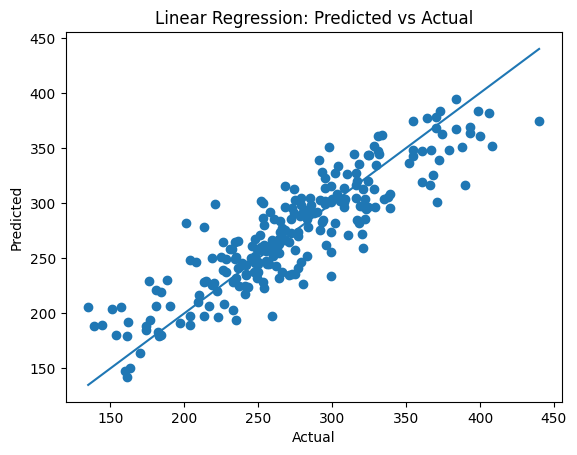

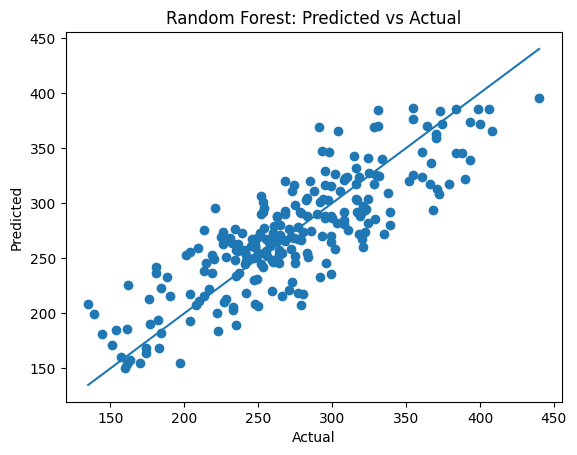

In [10]:
import matplotlib.pyplot as plt

# Linear Regression
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [11]:
# get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# get importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# combine into dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
7,cat__store_size_small,0.184408
14,num__is_festival,0.174561
5,cat__location_type_urban,0.141088
11,num__day_of_week,0.101210
8,num__competition_density,0.067342
13,num__is_weekend,0.060743
6,cat__store_size_medium,0.058783
10,num__month,0.056105
4,cat__location_type_semi-urban,0.040445
3,cat__promotion_type_loyalty_points,0.035196


Feature importance analysis from the Random Forest model shows that store size, day of the week, and location type are the most influential factors in predicting items sold.

In particular, smaller store sizes and urban locations appear to significantly impact sales patterns. Temporal features such as day of the week and month also play a key role, indicating that customer purchasing behaviour varies over time. Additionally, competition density influences sales, suggesting that stores in more competitive areas experience different demand levels.

These insights can help the business optimise promotion strategies based on store characteristics and timing.